In [1]:
from sklearn.model_selection import TimeSeriesSplit

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.preprocessing import StandardScaler

import joblib


In [2]:
import pandas as pd
df = pd.read_excel(
    "MCRFPUS1m.xls"
)
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,NaN,Workbook Contents,NaN,NaN,NaN,NaN
1,NaN,U.S. Field Production of Crude Oil (Thousand B...,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Click worksheet name or tab at bottom for data,NaN,NaN,NaN,NaN
4,NaN,Worksheet Name,Description,# Of Series,Frequency,Latest Data for


In [3]:
df = pd.read_excel(
    "MCRFPUS1m.xls",
    sheet_name="Data 1"
)

df.head()

,Back to Contents,Data 1: U.S. Field Production of Crude Oil (Thousand Barrels)
0,Sourcekey,MCRFPUS1
1,Date,U.S. Field Production of Crude Oil (Thousand B...
2,1920-01-15 00:00:00,34008
3,1920-02-15 00:00:00,33193
4,1920-03-15 00:00:00,36171


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1277 entries, 0 to 1276
Data columns (total 2 columns):
 #   Column                                                         Non-Null Count  Dtype 
---  ------                                                         --------------  ----- 
 0   Back to Contents                                               1277 non-null   object
 1   Data 1: U.S. Field Production of Crude Oil (Thousand Barrels)  1277 non-null   object
dtypes: object(2)
memory usage: 20.1+ KB


In [5]:
print(df.dtypes)

Back to Contents                                                 object
Data 1: U.S. Field Production of Crude Oil (Thousand Barrels)    object
dtype: object


In [6]:
df.head(10)

,Back to Contents,Data 1: U.S. Field Production of Crude Oil (Thousand Barrels)
0,Sourcekey,MCRFPUS1
1,Date,U.S. Field Production of Crude Oil (Thousand B...
2,1920-01-15 00:00:00,34008
3,1920-02-15 00:00:00,33193
4,1920-03-15 00:00:00,36171
5,1920-04-15 00:00:00,34945
6,1920-05-15 00:00:00,36622
7,1920-06-15 00:00:00,36663
8,1920-07-15 00:00:00,37746
9,1920-08-15 00:00:00,38906


In [7]:
import pandas as pd

df = pd.read_excel(
    "MCRFPUS1m.xls",
    sheet_name="Data 1"
)

df.columns = ["Date", "Production"]

# Remove first two metadata rows
df = df.iloc[2:]

# Remove the row containing the word "Date"
df = df[df["Date"] != "Date"]

# Convert data types
df["Date"] = pd.to_datetime(df["Date"])
df["Production"] = pd.to_numeric(df["Production"])

# Reset index
df.reset_index(drop=True, inplace=True)

df.head()

,Date,Production
0,1920-01-15,34008
1,1920-02-15,33193
2,1920-03-15,36171
3,1920-04-15,34945
4,1920-05-15,36622


In [8]:
df.isnull().sum()

Date          0
Production    0
dtype: int64

In [9]:
print(df.dtypes)

Date          datetime64[us]
Production             int64
dtype: object


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        1275 non-null   datetime64[us]
 1   Production  1275 non-null   int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 20.1 KB


In [11]:
print(f"Shape: {df.shape}")

Shape: (1275, 2)


In [12]:
print(df["Date"].min())
print(df["Date"].max())

1920-01-15 00:00:00
2026-03-15 00:00:00


In [13]:
df.describe()

,Date,Production
count,1275,1275.000000
mean,1973-02-13 08:51:57.176470,199370.100392
min,1920-01-15 00:00:00,33193.000000
25%,1946-07-30 12:00:00,145468.500000
50%,1973-02-15 00:00:00,201763.000000
75%,1999-08-30 12:00:00,259583.500000
max,2026-03-15 00:00:00,429777.000000
std,NaN,86379.860990


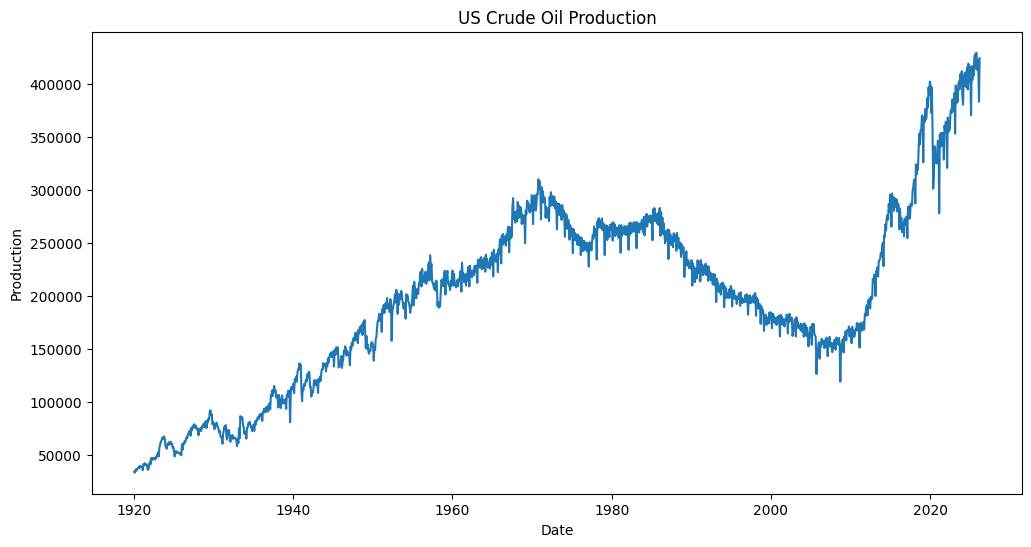

In [14]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Production"])
plt.xlabel("Date")
plt.ylabel("Production")
plt.title("US Crude Oil Production")
plt.show()

In [15]:
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

In [16]:
df.head()

,Date,Production,Month,Year
0,1920-01-15,34008,1,1920
1,1920-02-15,33193,2,1920
2,1920-03-15,36171,3,1920
3,1920-04-15,34945,4,1920
4,1920-05-15,36622,5,1920


In [17]:
monthly_avg = df.groupby("Month")["Production"].mean()
print(monthly_avg)

Month
1     202450.214953
2     186021.074766
3     205026.775701
4     196275.971698
5     201593.405660
6     195203.235849
7     201421.952830
8     202025.433962
9     195476.075472
10    203708.216981
11    198481.594340
12    204800.764151
Name: Production, dtype: float64


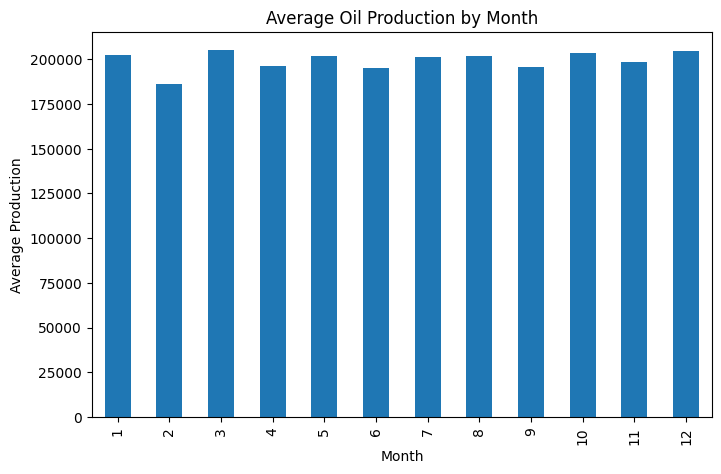

In [18]:
monthly_avg.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Oil Production by Month")
plt.xlabel("Month")
plt.ylabel("Average Production")
plt.show()

In [19]:
df["lag_1"] = df["Production"].shift(1)
df[["Date", "Production", "lag_1"]].head(10)

,Date,Production,lag_1
0,1920-01-15,34008,NaN
1,1920-02-15,33193,34008.0
2,1920-03-15,36171,33193.0
3,1920-04-15,34945,36171.0
4,1920-05-15,36622,34945.0
5,1920-06-15,36663,36622.0
6,1920-07-15,37746,36663.0
7,1920-08-15,38906,37746.0
8,1920-09-15,37521,38906.0
9,1920-10-15,39584,37521.0


In [20]:
df["lag_3"] = df["Production"].shift(3)
df["lag_6"] = df["Production"].shift(6)
df["lag_12"] = df["Production"].shift(12)

In [21]:
df[
    ["Date",
     "Production",
     "lag_1",
     "lag_3",
     "lag_6",
     "lag_12"]
].head(15)

,Date,Production,lag_1,lag_3,lag_6,lag_12
0,1920-01-15,34008,NaN,NaN,NaN,NaN
1,1920-02-15,33193,34008.0,NaN,NaN,NaN
2,1920-03-15,36171,33193.0,NaN,NaN,NaN
3,1920-04-15,34945,36171.0,34008.0,NaN,NaN
4,1920-05-15,36622,34945.0,33193.0,NaN,NaN
5,1920-06-15,36663,36622.0,36171.0,NaN,NaN
6,1920-07-15,37746,36663.0,34945.0,34008.0,NaN
7,1920-08-15,38906,37746.0,36622.0,33193.0,NaN
8,1920-09-15,37521,38906.0,36663.0,36171.0,NaN
9,1920-10-15,39584,37521.0,37746.0,34945.0,NaN


In [22]:
df["rolling_mean_3"] = df["Production"].rolling(3).mean()

df[
    ["Date",
     "Production",
     "rolling_mean_3"]
].head(10)

,Date,Production,rolling_mean_3
0,1920-01-15,34008,NaN
1,1920-02-15,33193,NaN
2,1920-03-15,36171,34457.333333
3,1920-04-15,34945,34769.666667
4,1920-05-15,36622,35912.666667
5,1920-06-15,36663,36076.666667
6,1920-07-15,37746,37010.333333
7,1920-08-15,38906,37771.666667
8,1920-09-15,37521,38057.666667
9,1920-10-15,39584,38670.333333


In [23]:
df["rolling_mean_6"] = df["Production"].rolling(6).mean()

df["rolling_mean_12"] = df["Production"].rolling(12).mean()

In [24]:
df.isnull().sum

<bound method DataFrame.sum of        Date  Production  Month   Year  lag_1  lag_3  lag_6  lag_12  \
0     False       False  False  False   True   True   True    True   
1     False       False  False  False  False   True   True    True   
2     False       False  False  False  False   True   True    True   
3     False       False  False  False  False  False   True    True   
4     False       False  False  False  False  False   True    True   
...     ...         ...    ...    ...    ...    ...    ...     ...   
1270  False       False  False  False  False  False  False   False   
1271  False       False  False  False  False  False  False   False   
1272  False       False  False  False  False  False  False   False   
1273  False       False  False  False  False  False  False   False   
1274  False       False  False  False  False  False  False   False   

      rolling_mean_3  rolling_mean_6  rolling_mean_12  
0               True            True             True  
1               

In [25]:
df.isnull().sum()

Date                0
Production          0
Month               0
Year                0
lag_1               1
lag_3               3
lag_6               6
lag_12             12
rolling_mean_3      2
rolling_mean_6      5
rolling_mean_12    11
dtype: int64

In [26]:
df.dropna()

,Date,Production,Month,Year,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12
12,1921-01-15,38138,1,1921,38961.0,39584.0,37746.0,34008.0,38569.333333,38619.833333,37254.916667
13,1921-02-15,35524,2,1921,38138.0,38609.0,38906.0,33193.0,37541.000000,38056.166667,37449.166667
14,1921-03-15,41105,3,1921,35524.0,38961.0,37521.0,36171.0,38255.666667,38653.500000,37860.333333
15,1921-04-15,40233,4,1921,41105.0,38138.0,39584.0,34945.0,38954.000000,38761.666667,38301.000000
16,1921-05-15,42189,5,1921,40233.0,35524.0,38609.0,36622.0,41175.666667,39358.333333,38764.916667
...,...,...,...,...,...,...,...,...,...,...,...
1270,2025-11-15,413677,11,2025,429777.0,428114.0,416844.0,401875.0,419433.000000,419942.333333,412676.833333
1271,2025-12-15,423356,12,2025,413677.0,414845.0,408315.0,416555.0,422270.000000,422449.166667,413243.583333
1272,2026-01-15,412456,1,2026,423356.0,429777.0,424926.0,407352.0,416496.333333,420370.833333,413668.916667
1273,2026-02-15,383507,2,2026,412456.0,413677.0,428114.0,370707.0,406439.666667,412936.333333,414735.583333


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             1275 non-null   datetime64[us]
 1   Production       1275 non-null   int64         
 2   Month            1275 non-null   int32         
 3   Year             1275 non-null   int32         
 4   lag_1            1274 non-null   float64       
 5   lag_3            1272 non-null   float64       
 6   lag_6            1269 non-null   float64       
 7   lag_12           1263 non-null   float64       
 8   rolling_mean_3   1273 non-null   float64       
 9   rolling_mean_6   1270 non-null   float64       
 10  rolling_mean_12  1264 non-null   float64       
dtypes: datetime64[us](1), float64(7), int32(2), int64(1)
memory usage: 99.7 KB


In [28]:
df.head()

,Date,Production,Month,Year,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12
0,1920-01-15,34008,1,1920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1920-02-15,33193,2,1920,34008.0,NaN,NaN,NaN,NaN,NaN,NaN
2,1920-03-15,36171,3,1920,33193.0,NaN,NaN,NaN,34457.333333,NaN,NaN
3,1920-04-15,34945,4,1920,36171.0,34008.0,NaN,NaN,34769.666667,NaN,NaN
4,1920-05-15,36622,5,1920,34945.0,33193.0,NaN,NaN,35912.666667,NaN,NaN


In [29]:
df = df[df["Date"] >= "1980-01-01"].copy()
df.reset_index(drop=True, inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             555 non-null    datetime64[us]
 1   Production       555 non-null    int64         
 2   Month            555 non-null    int32         
 3   Year             555 non-null    int32         
 4   lag_1            555 non-null    float64       
 5   lag_3            555 non-null    float64       
 6   lag_6            555 non-null    float64       
 7   lag_12           555 non-null    float64       
 8   rolling_mean_3   555 non-null    float64       
 9   rolling_mean_6   555 non-null    float64       
 10  rolling_mean_12  555 non-null    float64       
dtypes: datetime64[us](1), float64(7), int32(2), int64(1)
memory usage: 43.5 KB


In [30]:
print(df["Date"].min())
print(df["Date"].max())
print(df.shape)

1980-01-15 00:00:00
2026-03-15 00:00:00
(555, 11)


In [31]:
features = [
    "Month",
    "Year",
    "lag_1",
    "lag_3",
    "lag_6",
    "lag_12",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_12"
]

X = df[features]

y = df["Production"]

In [32]:
print(X.shape)
print(y.shape)
X.head()

(555, 9)
(555,)


,Month,Year,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12
0,1,1980,267050.0,267256.0,259278.0,262716.0,266269.333333,264456.333333,260627.833333
1,2,1980,268940.0,262818.0,264981.0,238710.0,262807.000000,262364.666667,261771.250000
2,3,1980,252431.0,267050.0,255693.0,266635.0,263673.666667,264690.833333,262022.500000
3,4,1980,269650.0,268940.0,267256.0,256593.0,260874.000000,263571.666667,262351.500000
4,5,1980,260541.0,252431.0,262818.0,266631.0,265958.333333,264382.666667,262439.250000


In [33]:
corr = df[
    [
        "Production",
        "lag_1",
        "lag_3",
        "lag_6",
        "lag_12",
        "rolling_mean_3",
        "rolling_mean_6",
        "rolling_mean_12"
    ]
].corr()

corr

,Production,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12
Production,1.000000,0.983137,0.983083,0.971755,0.966963,0.994955,0.992621,0.986696
lag_1,0.983137,1.000000,0.985616,0.981280,0.956386,0.994094,0.992812,0.988671
lag_3,0.983083,0.985616,1.000000,0.982804,0.967375,0.989263,0.993714,0.991606
lag_6,0.971755,0.981280,0.982804,1.000000,0.970358,0.983076,0.987634,0.992661
lag_12,0.966963,0.956386,0.967375,0.970358,1.000000,0.967851,0.973248,0.982567
rolling_mean_3,0.994955,0.994094,0.989263,0.983076,0.967851,1.000000,0.998392,0.993913
rolling_mean_6,0.992621,0.992812,0.993714,0.987634,0.973248,0.998392,1.000000,0.997378
rolling_mean_12,0.986696,0.988671,0.991606,0.992661,0.982567,0.993913,0.997378,1.000000


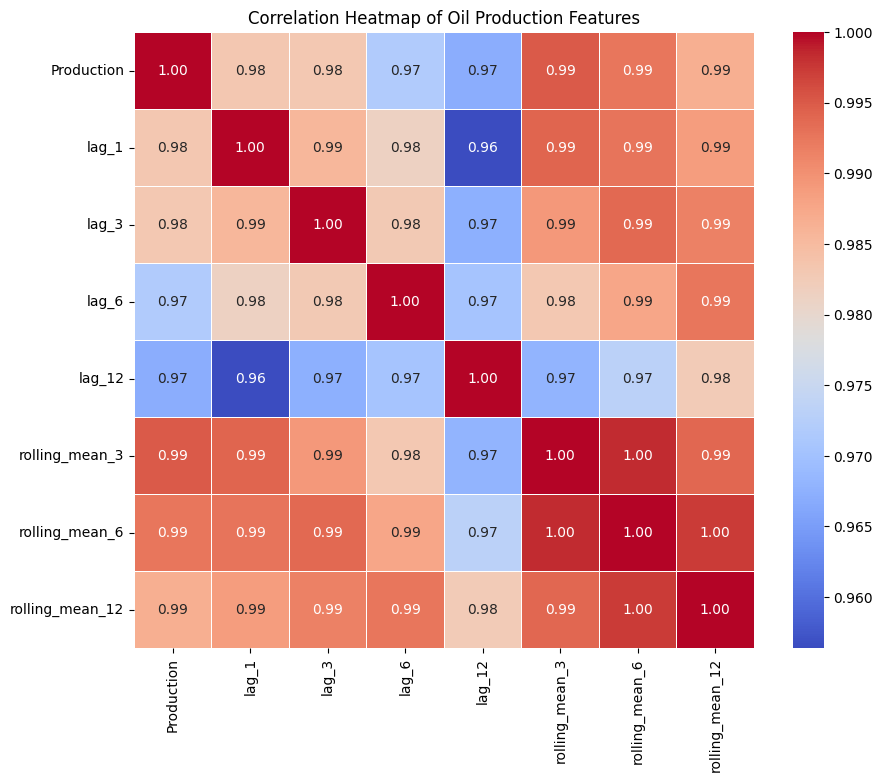

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[
    [
        "Production",
        "lag_1",
        "lag_3",
        "lag_6",
        "lag_12",
        "rolling_mean_3",
        "rolling_mean_6",
        "rolling_mean_12"
    ]
].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,      # show numbers
    fmt=".2f",       # 2 decimal places
    cmap="coolwarm", # color scheme
    linewidths=0.5
)

plt.title("Correlation Heatmap of Oil Production Features")
plt.show()

In [35]:
tscv = TimeSeriesSplit(n_splits=5)

In [36]:
for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    
    print(f"\nSplit {i+1}")
    
    print("Train Size:", len(train_idx))
    print("Test Size :", len(test_idx))
    
    print("Train End Index:", train_idx[-1])
    print("Test Start Index:", test_idx[0])


Split 1
Train Size: 95
Test Size : 92
Train End Index: 94
Test Start Index: 95

Split 2
Train Size: 187
Test Size : 92
Train End Index: 186
Test Start Index: 187

Split 3
Train Size: 279
Test Size : 92
Train End Index: 278
Test Start Index: 279

Split 4
Train Size: 371
Test Size : 92
Train End Index: 370
Test Start Index: 371

Split 5
Train Size: 463
Test Size : 92
Train End Index: 462
Test Start Index: 463


In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

(555, 9)


In [38]:
print(X_scaled[:5])

[[-1.58301992 -1.69470018  0.33373883  0.34585158  0.25251476  0.33552311
   0.32429819  0.30757222  0.27165035]
 [-1.29391954 -1.69470018  0.35949051  0.28489312  0.33217252 -0.01116037
   0.27690427  0.27868973  0.2877435 ]
 [-1.00481916 -1.69470018  0.13455164  0.34302205  0.20244058  0.39211948
   0.28876758  0.31081028  0.29127975]
 [-0.71571878 -1.69470018  0.36916442  0.36898228  0.36394903  0.24709759
   0.25044452  0.29535642  0.29591029]
 [-0.4266184  -1.69470018  0.24505223  0.14222174  0.3019604   0.39206171
   0.32004109  0.306555    0.29714534]]


In [39]:
mae_scores = []
mse_scores = []
r2_scores = []

In [40]:
for train_idx, test_idx in tscv.split(X):
print("Train: ", len(train_idx))
print("Test: ", len(test_idx))
break

IndentationError: expected an indented block after 'for' statement on line 1 (3630036567.py, line 2)

In [ ]:
for train_idx, test_idx in tscv.split(X):
    
    print("TRAIN:", len(train_idx))
    print("TEST :", len(test_idx))
    
    break

In [41]:
for train_idx, test_idx in tscv.split(X):
    
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    break

In [42]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(95, 9)
(92, 9)
(95,)
(92,)


In [43]:
scaler = StandardScaler()

In [44]:
X_train_scaled = scaler.fit_transform(X_train)

In [45]:
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = linearRegression()

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train_scaled, y_train)

In [ ]:
y_pred = model.predict(
    x_test_scaled)

In [ ]:
y_pred = model.predict(
    X_test_scaled
)

In [ ]:
y_pred = model.predict(
    X_test_scaled
)

In [ ]:
print(y_pred[:10])

In [ ]:
mae = mean_absolute_error(
    y_test,
    y_pred
)
print("MAE: ", mae)

In [ ]:
rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

print("RMSE:", rmse)

In [ ]:
r2 = r2_score (
    y_test,
    y_pred
)
print("R2_Score: ", r2)

In [ ]:
import pandas as pd 
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "predicted": y_pred
})
comparison.head(10)

In [ ]:
for train_idx, test_idx in tscv.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)

    X_test_scaled = scaler.transform(X_test)

    model = LinearRegression()

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = mean_squared_error(
        y_test,
        y_pred
    ) ** 0.5

    r2 = r2_score(
        y_test,
        y_pred
    )

    mae_scores.append(mae)

    rmse_scores.append(rmse)

    r2_scores.append(r2)

In [ ]:
mae_scores = []
rmse_scores = []
r2_scores = []

In [ ]:
for train_idx, test_idx in tscv.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LinearRegression()

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = mean_squared_error(y_test, y_pred) ** 0.5

    r2 = r2_score(y_test, y_pred)

    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

In [ ]:
print("MAE Scores:")
print(mae_scores)

print("\nRMSE Scores:")
print(rmse_scores)

print("\nR2 Scores:")
print(r2_scores)

In [ ]:
print("Average MAE :", sum(mae_scores) / len(mae_scores))
print("Average RMSE :", sum(rmse_scores) / len(rmse_scores))
print("Average R2 :", sum(r2_scores) / len(r2_scores))

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_mae_scores = []
rf_rmse_scores = []
rf_r2_scores = []

In [ ]:
for train_idx, test_idx in tscv.split(X):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = RandomForestRressor(
    n_estimates = 100, 
    random_state = 42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
     mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = mean_squared_error(
        y_test,
        y_pred
    ) ** 0.5

    r2 = r2_score(
        y_test,
        y_pred
    )
rf_mae_scores.append(mae)
rf_rmse_scores.append(rmse)
rf_r2_scores.append(r2_scores)

In [ ]:
for train_idx, test_idx in tscv.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = mean_squared_error(
        y_test,
        y_pred
    ) ** 0.5

    r2 = r2_score(
        y_test,
        y_pred
    )

    rf_mae_scores.append(mae)
    rf_rmse_scores.append(rmse)
    rf_r2_scores.append(r2)

In [ ]:
print("RF MAE:", rf_mae_scores)

print("RF RMSE:", rf_rmse_scores)

print("RF R2:", rf_r2_scores)

In [ ]:
print(
    "RF Average MAE:",
    sum(rf_mae_scores) / len(rf_mae_scores)
)

print(
    "RF Average RMSE:",
    sum(rf_rmse_scores) / len(rf_rmse_scores)
)

print(
    "RF Average R2:",
    sum(rf_r2_scores) / len(rf_r2_scores)
)

In [ ]:
print(X.shape)

In [ ]:
print(X.shape)
print(df.shape)

In [ ]:
import xgboost as xgb

In [ ]:
xgb_mae_scores = []
xgb_rmse_scores = []
xgb_r2_scores = []

In [ ]:
for train_idx, test_idx in tscv.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = mean_squared_error(
        y_test,
        y_pred
    ) ** 0.5

    r2 = r2_score(
        y_test,
        y_pred
    )

    xgb_mae_scores.append(mae)
    xgb_rmse_scores.append(rmse)
    xgb_r2_scores.append(r2)

In [ ]:
print("XGB MAE:", xgb_mae_scores)

print("XGB RMSE:", xgb_rmse_scores)

print("XGB R2:", xgb_r2_scores)

In [ ]:
print(
    "XGB Average MAE:",
    sum(xgb_mae_scores) / len(xgb_mae_scores)
)

print(
    "XGB Average RMSE:",
    sum(xgb_rmse_scores) / len(xgb_rmse_scores)
)

print(
    "XGB Average R2:",
    sum(xgb_r2_scores) / len(xgb_r2_scores)
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(
    X_train_scaled,
    y_train
)

lr_train_pred = lr_model.predict(
    X_train_scaled
)

lr_test_pred = lr_model.predict(
    X_test_scaled
)

In [ ]:
residuals = y_train - lr_train_pred

print(residuals.describe())

In [ ]:
from xgboost import XGBRegressor

xgb_residual = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

xgb_residual.fit(
    X_train,
    residuals
)

In [ ]:
residual_pred = xgb_residual.predict(
    X_test
)

In [ ]:
hybrid_pred = (
    lr_test_pred
    +
    residual_pred
)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    hybrid_pred
)

rmse = mean_squared_error(
    y_test,
    hybrid_pred
) ** 0.5

r2 = r2_score(
    y_test,
    hybrid_pred
)

print("Hybrid MAE :", mae)
print("Hybrid RMSE:", rmse)
print("Hybrid R2  :", r2)

In [ ]:
print("LR R2 :", sum(r2_scores)/len(r2_scores))
print("RF R2 :", sum(rf_r2_scores)/len(rf_r2_scores))
print("XGB R2:", sum(xgb_r2_scores)/len(xgb_r2_scores))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title("Feature Importance (Absolute Coefficients)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title("Feature Importance (Absolute Coefficients)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

lr_model = LinearRegression()

lr_model.fit(X_scaled, y)

In [ ]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

coef_df

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title("Linear Regression Feature Importance")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(
    y_test.values,
    label="Actual"
)
plt.plot(
    y_pred, 
    label="Predicted"
)
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.show()

In [ ]:
print(len(y_test))
print(len(y_pred))

In [ ]:
print(y_test[:5])
print(y_pred[:5])

In [ ]:
comparison.head(10)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# First split only
for train_idx, test_idx in tscv.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    lr_model = LinearRegression()

    lr_model.fit(X_train_scaled, y_train)

    lr_pred = lr_model.predict(X_test_scaled)

    break

In [ ]:

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": lr_pred
})

comparison.head(10)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    lr_pred,
    label="Predicted"
)

plt.title("Linear Regression: Actual vs Predicted")

plt.xlabel("Observations")
plt.ylabel("Production")

plt.legend()
plt.savefig("Linear Regression: Actual vs Predicted")
plt.show()

In [ ]:
residuals = y_test.values - lr_pred
print("Residual mean: ", residuals.mean())
print("Residuals std: ", residuals.std())

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(
    residuals,
    bins = 20
)
plt.title("Residual distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print("Residual Mean:", residuals.mean())
print("Residual Median:", residuals.mean())

In [ ]:
from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
final_model = LinearRegression()
final_model.fit(X_scaled, y) 
print("Final Model Trained!")

In [ ]:
df.tail()

In [ ]:
history = list(df["Production"])
print("History length: ", len(history))
print("Last value: ", history[-1])

In [ ]:
future_dates = pd.data_range(
    start = df["Date"].max() + pd.DateOffset(months=1),
    periods=60,
    freq='MS'
)
future_dates 

In [ ]:
future_dates = pd.date_range(
    start = df["Date"].max() + pd.DateOffset(months=1),
    periods=60,
    freq='MS'
)
future_dates 

In [ ]:
future_predictions = []

In [ ]:
for date in future_dates:

In [ ]:
for date in future_dates:
    lag_1 = history[-1]
    lag_3 = history[-3]
    lag_6 = history[-6]
    lag_12 = history[-12]

In [ ]:
rolling_mean_3 = sum(history[-3:]) / 3

rolling_mean_6 = sum(history[-6:]) / 6

rolling_mean_12 = sum(history[-12:]) / 12

In [ ]:
for date in future_dates:

    # Lag Features
    lag_1 = history[-1]
    lag_3 = history[-3]
    lag_6 = history[-6]
    lag_12 = history[-12]

    # Rolling Means
    rolling_mean_3 = sum(history[-3:]) / 3
    rolling_mean_6 = sum(history[-6:]) / 6
    rolling_mean_12 = sum(history[-12:]) / 12

    # Date Features
    month = date.month
    year = date.year

    # Create feature row
    future_row = pd.DataFrame({
        "Month": [month],
        "Year": [year],
        "lag_1": [lag_1],
        "lag_3": [lag_3],
        "lag_6": [lag_6],
        "lag_12": [lag_12],
        "rolling_mean_3": [rolling_mean_3],
        "rolling_mean_6": [rolling_mean_6],
        "rolling_mean_12": [rolling_mean_12]
    })

    # Scale features
    future_row_scaled = scaler.transform(future_row)

    # Predict
    prediction = final_model.predict(future_row_scaled)[0]

    # Store prediction
    future_predictions.append(prediction)

    # Add prediction to history
    history.append(prediction)

In [ ]:
forecast_df = pd.DataFrame({

In [ ]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast": future_predictions
    )}

In [ ]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast": future_predictions
})

In [ ]:
forecast_df.head()

In [ ]:
forecast_df.tail()

In [ ]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(14, 6))

In [ ]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(14, 6))
plt.plot(
    df["Date"], 
    df["Production"],
    label="Historical Production"
)
plt.plot(
    df["Date"],
    df["Forecast"],
    label="Forecast (2026-2031)"
)
plt.title("U.S Crude Oil Production Foreacast (Next 5 years)")
plt.xlabel("Year")
plt.ylabel("Production")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

plt.plot(
    df["Date"],
    df["Production"],
    label="Historical Production"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecast"],
    label="Forecast (2026-2031)"
)

plt.title(
    "U.S. Crude Oil Production Forecast (Next 5 Years)"
)

plt.xlabel("Year")
plt.ylabel("Production")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
forecast_df.describe()

In [ ]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Production"])
plt.xlabel("Date")
plt.ylabel("Production")
plt.title("US Crude Oil Production")
plt.show()

In [ ]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Production"])
plt.xlabel("Date")
plt.ylabel("Production")
plt.title("US Crude Oil Production")
plt.savefig("US Crude Oil Production")
plt.show()

In [ ]:
monthly_avg.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Oil Production by Month")
plt.xlabel("Month")
plt.ylabel("Average Production")
plt.savefig("Monthly Trends of Oil Production")
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[
    [
        "Production",
        "lag_1",
        "lag_3",
        "lag_6",
        "lag_12",
        "rolling_mean_3",
        "rolling_mean_6",
        "rolling_mean_12"
    ]
].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,      # show numbers
    fmt=".2f",       # 2 decimal places
    cmap="coolwarm", # color scheme
    linewidths=0.5
)

plt.title("Correlation Heatmap of Oil Production Features")
plt.savefig("Correlation Heatmap")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title("Linear Regression Feature Importance")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.savefig("Linear Regression Feature Importance", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title("Linear Regression Feature Importance")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.savefig("Linear Regression Feature Importance", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title("Linear Regression Feature Importance")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

plt.show()

In [ ]:
print(type(model))

In [ ]:
coef_df.head()

In [ ]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df["Abs_Coefficient"] = abs(coef_df["Coefficient"])

coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title("Linear Regression Feature Importance")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(
    y_test.values,
    label="Actual"
)
plt.plot(
    y_pred, 
    label="Predicted"
)
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.savefig("Linear Regression: Actual vs Predicted")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    lr_pred,
    label="Predicted"
)

plt.title("Linear Regression: Actual vs Predicted")

plt.xlabel("Observations")
plt.ylabel("Production")

plt.legend()
plt.savefig("Linear Regression: Actual vs Predicted")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    lr_pred,
    label="Predicted"
)

plt.title("Linear Regression: Actual vs Predicted")

plt.xlabel("Observations")
plt.ylabel("Production")

plt.legend()
plt.savefig("Linear Regression Actual vs Predicted.png")
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(
    residuals,
    bins = 20
)
plt.title("Residual distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.savefig("Residual distribution.png")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

plt.plot(
    df["Date"],
    df["Production"],
    label="Historical Production"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecast"],
    label="Forecast (2026-2031)"
)

plt.title(
    "U.S. Crude Oil Production Forecast (Next 5 Years)"
)

plt.xlabel("Year")
plt.ylabel("Production")

plt.legend()

plt.grid(True)
plt.savefig("U.S. Crude Oil Production Forecast.png")

plt.show()

In [ ]:
print("Notebook working")

In [ ]:
import statsmodels
print(statsmodels._version)

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

print("ARIMA Imported Successfully")

In [ ]:
from statsmodels.tsa.arima.model import ARIMA 
production = df["Production"]
arima_model = ARIMA(
    production, 
    order=(5, 1, 0)
)
arima_fit = arima_model.fit()
print("ARIMA Model trained Successfully")

In [ ]:
import pandas as pd

df = pd.read_excel(
    "MCRFPUS1m.xls",
    sheet_name="Data 1"
)

print(df.head())

In [ ]:
print(df.columns)

In [ ]:
df["Production"].head()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

print("ARIMA Imported Successfully")

In [ ]:
from statsmodels.tsa.arima.model import ARIMA 
production = df["Production"]
arima_model = ARIMA(
    production, 
    order=(5, 1, 0)
)
arima_fit = arima_model.fit()
print("ARIMA Model trained Successfully")

In [ ]:
from statsmodels.tsa.arima.model import ARIMA 
production = df["Production"]
arima_model = ARIMA(
    production, 
    order=(5, 1, 0)
)
arima_fit = arima_model.fit()
print("ARIMA Model trained Successfully")

In [ ]:
print(arima_fit.summary())

In [ ]:
residuals = arima_fit.residuals()
print(residuals.head())
print(residuals.shape)

In [ ]:
residuals = arima_fit.resid()
print(residuals.head())
print(residuals.shape)

In [ ]:
residuals = arima_fit.resid()

print(residuals.head())
print(residuals.shape)

In [ ]:
residuals = arima_fit.resid

print(residuals.head())
print(residuals.shape)

In [ ]:
residuals.describe()

In [ ]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(12, 6))
plt.plot(residuals)
plt.title("ARIMA Residuals")
plt.xlabel("Time")
plt.ylabel("Residuals")
plt.savefig(
            "ARIMA Residuals.png", 
            dpi = 300, 
            bbox_inches="tight"
)
plt.show()

In [ ]:
residuals_no_first = residuals[1:]

plt.figure(figsize=(12,6))

plt.plot(residuals_no_first)

plt.title("ARIMA Residuals (Without First Observation)")
plt.xlabel("Time")
plt.ylabel("Residual")

plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(residuals_no_first, bins=30)
plt.title("Distribution of ARIMA Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

In [ ]:
forecast_arima = arima_fit.forecast(steps=60)
print(forecast_arima.head())
print(forecast_arima.tail())

In [ ]:
train_size = int(len(df)*0.8)
train = df["Production"][:train_size]
test = df["Production"][train_size:]
print("Train:", train.shape)
print("Test:", test.shape)

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(
    train,
    order=(5,1,0)
)

arima_fit = arima_model.fit()

print("ARIMA trained")

In [ ]:
arima_pred = arima_model.forecast(
    steps=len(test)
)
print(arima_pred.head())

In [ ]:
arima_pred = arima_fit.forecast(
    steps=len(test)
)

print(arima_pred.head())

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    test,
    arima_pred
)

rmse = mean_squared_error(
    test,
    arima_pred
) ** 0.5

r2 = r2_score(
    test,
    arima_pred
)

print("ARIMA MAE :", mae)
print("ARIMA RMSE:", rmse)
print("ARIMA R2 :", r2)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "LR + XGB Hybrid",
        "Random Forest",
        "XGBoost",
        "ARIMA"
    ],
    "R2": [
        0.8809,
        0.8765,
        -1.0446,
        -1.1561,
        -4.5557
    ]
})

results = results.sort_values(
    by="R2",
    ascending=False
)

plt.figure(figsize=(10,5))

bars = plt.bar(
    results["Model"],
    results["R2"]
)

plt.title("Comparison of Forecasting Models using R² Score")
plt.ylabel("R² Score")
plt.xlabel("Models")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "Model_Comparison_R2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "LR + XGB Hybrid",
        "Random Forest",
        "XGBoost",
        "ARIMA"
    ],
    "R2": [
        0.8809,
        0.8765,
        -1.0446,
        -1.1561,
        -4.5557
    ]
})

results = results.sort_values(
    by="R2",
    ascending=False
)

plt.figure(figsize=(10,5))

bars = plt.bar(
    results["Model"],
    results["R2"]
)

plt.title("Comparison of Forecasting Models using R² Score")
plt.ylabel("R² Score")
plt.xlabel("Models")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "Model_Comparison_R2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(test.values, label="Actual")
plt.plot(arima_pred.values, label="ARIMA Prediction")

plt.legend()

plt.title("ARIMA: Actual vs Predicted")
plt.show()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(
    train,
    order=(2,1,2)
)

arima_fit = arima_model.fit()

print("ARIMA trained")

In [ ]:
arima_pred = arima_fit.forecast(
    steps=len(test)
)

print(arima_pred.head())

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    test,
    arima_pred
)

rmse = mean_squared_error(
    test,
    arima_pred
) ** 0.5

r2 = r2_score(
    test,
    arima_pred
)

print("ARIMA MAE :", mae)
print("ARIMA RMSE:", rmse)
print("ARIMA R2 :", r2)

In [ ]:
print("notebook working")

In [ ]:
from statsmodel.tsa.stattools import adfuller
result = adfuller(df["Production"])
print("ADF Statistics: ", result[0])
print("p-value: ", result[1])

In [ ]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df["Production"])
print("ADF Statistics: ", result[0])
print("p-value: ", result[1])

In [ ]:
production_diff = df["Production"].diff()
production_diff = production_diff.dropna()
print(production_diff.head())

In [ ]:
result = adfuller(production_diff)
print("ADF Statistic:", result[0])
print("p-value:", result[1])

In [ ]:
print("working")

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plot_pacf(
    production_diff,
    lags=30
)

plt.show()

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plot_acf(
    production_diff,
    lags=30
)

plt.show()

In [ ]:
print("working")

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

best_aic = float("inf")
best_order = None

for p in range(0, 6):
    for d in range(1, 2):   # we know d=1
        for q in range(0, 6):

            try:
                model = ARIMA(
                    train,
                    order=(p,d,q)
                )

                fit = model.fit()

                if fit.aic < best_aic:
                    best_aic = fit.aic
                    best_order = (p,d,q)

            except:
                continue

print("Best Order:", best_order)
print("Best AIC:", best_aic)

In [ ]:
print(best_order)
print(best_aic)

In [ ]:
print(type(train))
print(len(train))

In [ ]:
print(train.head())
print(train.tail())

In [ ]:
print(train.min())
print(train.max())

In [ ]:
print(len(train))
print(len(test))

In [ ]:
best_model = ARIMA(
    train,
    order=(5,1,3)
)

best_fit = best_model.fit()

print("Best ARIMA trained successfully")

In [ ]:
arima_pred = best_fit.forecast(
    steps=len(test)
)

print(arima_pred.head())
print(arima_pred.shape)

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(
    test,
    arima_pred
)

rmse = mean_squared_error(
    test,
    arima_pred
) ** 0.5

r2 = r2_score(
    test,
    arima_pred
)

print("ARIMA MAE :", mae)
print("ARIMA RMSE:", rmse)
print("ARIMA R2 :", r2)

In [ ]:
print(arima_pred.describe())

In [ ]:
print(best_fit.aic)

In [ ]:
print(arima_pred.head())
print(arima_pred.tail())

In [ ]:
print(best_fit.summary())

In [ ]:
model = ARIMA(
    train,
    order=(1,1,1)
)

fit = model.fit()

pred = fit.forecast(
    steps=len(test)
)

print(pred.head())
print(pred.describe())

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(
    test,
    pred
)

rmse = mean_squared_error(
    test,
    pred
) ** 0.5

r2 = r2_score(
    test,
    pred
)

print("ARIMA(1,1,1) MAE :", mae)
print("ARIMA(1,1,1) RMSE:", rmse)
print("ARIMA(1,1,1) R2 :", r2)

In [ ]:
print(X.shape)
print(y.shape)

In [ ]:
X_train
X_test
y_train
y_test

In [ ]:
print(X.head())
print(y.head())

In [ ]:
X_train = X[:444]
X_test = X[444:]

y_train = y[:444]
y_test = y[444:]

print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test
)

print("XGBoost trained successfully")

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    xgb_pred
)

rmse = mean_squared_error(
    y_test,
    xgb_pred
) ** 0.5

r2 = r2_score(
    y_test,
    xgb_pred
)

print("XGB MAE :", mae)
print("XGB RMSE:", rmse)
print("XGB R2  :", r2)

In [ ]:
print(X.columns)

In [ ]:
print(xgb_pred[:10])

In [ ]:
print(y_test.head(10))

In [ ]:
print(X.head())

In [ ]:
print(len(y_test))
print(len(xgb_pred))

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": xgb_pred
})

comparison.head(20)

In [ ]:
print(y_test.index[:5])

In [ ]:
print(xgb_pred[:5])

In [ ]:
comparison.head(10)
comparison["Error"].abs().mean()
len(y_test)
len(xgb_pred)

In [ ]:
comparison["Error"] = comparison["Actual"] - comparison["Predicted"]

comparison.head(10)

In [ ]:
print(comparison["Error"].abs().mean())

In [ ]:
comparison["Abs_Error"] = abs(
    comparison["Actual"] - comparison["Predicted"]
)

comparison.sort_values(
    by="Abs_Error",
    ascending=False
).head(20)

In [ ]:
comparison.tail(20)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    comparison["Actual"].values,
    label="Actual"
)

plt.plot(
    comparison["Predicted"].values,
    label="Predicted"
)

plt.legend()
plt.show()

In [ ]:
print(y_train.min(), y_train.max())
print(y_test.min(), y_test.max())